In [2]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.spatial import Delaunay

# ============================================================
# USER INPUTS
# ============================================================
spec_url = (
    "https://geoport.whoi.edu/thredds/dodsC/"
    "vortexfs1/usgs/Projects/Helene2024/helene77/Output_89pct/"
    "ww3.202409_spec.nc"
)

his_url = (
    "https://geoport.whoi.edu/thredds/dodsC/"
    "vortexfs1/usgs/Projects/Helene2024/helene77/Output_89pct/"
    "coawst_gomsab_his.nc"
)

HS_VAR = "Hwave"
TP_VAR = "Pwave_top"
DIR_VAR = "Dwave"

BULK_DIR_CONVENTION = "to"     # Dwave is assumed toward
BULK_DIR_UNITS = "deg"         # Dwave units are degrees

LON_NAME = "lon_rho"
LAT_NAME = "lat_rho"


# ============================================================
# HELPERS
# ============================================================
def wrap360(deg):
    return np.mod(deg, 360.0)


def circular_diff_deg(a, b):
    return (a - b + 180.0) % 360.0 - 180.0


def az_to_xy_geo(az_deg):
    az = np.deg2rad(az_deg)
    return np.sin(az), np.cos(az)   # east, north


def circular_mean_deg(dir_deg, weights):
    """
    Weighted circular mean.
    dir_deg should be geographic azimuth in degrees.
    weights must have matching last dimension.
    """
    ux, uy = az_to_xy_geo(dir_deg)
    x = np.sum(weights * ux, axis=-1)
    y = np.sum(weights * uy, axis=-1)
    return wrap360(np.degrees(np.arctan2(x, y)))


def circular_binwidths_rad(dir_deg):
    """
    Bin widths from unsorted circular direction centers.
    Returns widths in radians, in the original order.
    """
    d = wrap360(np.asarray(dir_deg, float))
    srt = np.argsort(d)
    ds = d[srt]

    ds_ext = np.r_[ds[-1] - 360.0, ds, ds[0] + 360.0]
    edges = 0.5 * (ds_ext[:-1] + ds_ext[1:])
    widths_sorted = np.diff(edges)

    widths = np.empty_like(widths_sorted)
    widths[np.argsort(srt)] = widths_sorted
    return np.deg2rad(widths)

# ============================================================
# Read the contour points
# ============================================================

def read_contour(contour_file = "contour30sp.csv"):
    df = pd.read_csv(contour_file)

    ds = xr.Dataset(
        coords={
            "point": np.arange(len(df))
        },
        data_vars={
            "lon":      ("point", df["contour30s_lon"].to_numpy()),
            "lat":      ("point", df["contour30s_lat"].to_numpy()),
            "x":        ("point", df["contour30s_x"].to_numpy()),
            "y":        ("point", df["contour30s_y"].to_numpy()),
            "normal_x": ("point", df["normals30_x"].to_numpy()),
            "normal_y": ("point", df["normals30_y"].to_numpy()),
        }
    )
    # flip the sign because normals to the tangents point offshore
    ds["normal_x"] = -ds["normal_x"]
    ds["normal_y"] = -ds["normal_y"]
    return ds

contour_ds = read_contour()
contour_ds


# ============================================================
# READ COAWST / WW3 2D SPECTRA
# ============================================================
def read_coawst_2dspec(url, contour_ds=None):
    ds0 = xr.open_dataset(url)

    time = ds0["time"].values
    freq = ds0["frequency"].values
    dir_from_deg = ds0["direction"].values   # native directions are FROM
    S = ds0["efth"].values                   # (time, station, frequency, direction)

    ds = xr.Dataset(
        coords={
            "time": time,
            "point": np.arange(S.shape[1]),
            "freq": freq,
            "dir": dir_from_deg,
        },
        data_vars={
            "spec": (("time", "point", "freq", "dir"), S),
        },
        attrs={
            "model": "COAWST/WW3",
            "dir_convention": "from",
            "dir_frame": "geographic",
            "spec_units": "m^2/Hz/rad",
        }
    )

    if contour_ds is not None:
        ds = ds.assign_coords(
            lon=("point", contour_ds["lon"].values),
            lat=("point", contour_ds["lat"].values),
            x=("point", contour_ds["x"].values),
            y=("point", contour_ds["y"].values),
        )
        ds["normal_x"] = ("point", contour_ds["normal_x"].values)
        ds["normal_y"] = ("point", contour_ds["normal_y"].values)

    return ds


# ============================================================
# CALCULATE BULK STATS FROM 2D SPECTRA
# ============================================================
def calc_coawst_spec_stats(ds_cw):
    """
    Compute spectral bulk stats from ds_cw['spec'].

    Returns Dataset with:
      m0_spec
      hm0_spec
      tp_spec
      dir_mean_from_spec
      dir_mean_to_spec
      dir_peak_from_spec
      dir_peak_to_spec
    """
    S = ds_cw["spec"].values                 # (time, point, freq, dir)
    f = ds_cw["freq"].values
    d_from = ds_cw["dir"].values             # geographic FROM

    dtheta = circular_binwidths_rad(d_from)  # (dir,)

    # Integrate over direction -> 1D frequency spectrum
    Ef = np.sum(S * dtheta[None, None, None, :], axis=-1)   # (time, point, freq)

    m0 = np.trapezoid(Ef, x=f, axis=-1)
    hm0 = 4.0 * np.sqrt(m0)

    ipk = np.argmax(Ef, axis=-1)
    fp = f[ipk]
    tp = 1.0 / fp

    # Energy-weighted mean direction
    Sdir = np.trapezoid(S, x=f, axis=2)      # (time, point, dir)
    dir_mean_from = circular_mean_deg(d_from[None, None, :], Sdir * dtheta[None, None, :])
    dir_mean_to = wrap360(dir_mean_from + 180.0)

    # Peak direction at peak frequency
    nt, npnt, nf, nd = S.shape
    dir_peak_from = np.full((nt, npnt), np.nan, dtype=float)
    for it in range(nt):
        for ip in range(npnt):
            jf = ipk[it, ip]
            jd = np.argmax(S[it, ip, jf, :])
            dir_peak_from[it, ip] = d_from[jd]

    dir_peak_to = wrap360(dir_peak_from + 180.0)

    ds_out = xr.Dataset(
        coords={"time": ds_cw["time"], "point": ds_cw["point"]},
        data_vars={
            "m0_spec": (("time", "point"), m0.astype(np.float32)),
            "hm0_spec": (("time", "point"), hm0.astype(np.float32)),
            "tp_spec": (("time", "point"), tp.astype(np.float32)),
            "dir_mean_from_spec": (("time", "point"), dir_mean_from.astype(np.float32)),
            "dir_mean_to_spec": (("time", "point"), dir_mean_to.astype(np.float32)),
            "dir_peak_from_spec": (("time", "point"), dir_peak_from.astype(np.float32)),
            "dir_peak_to_spec": (("time", "point"), dir_peak_to.astype(np.float32)),
        }
    )

    ds_out["hm0_spec"].attrs["units"] = "m"
    ds_out["tp_spec"].attrs["units"] = "s"
    ds_out["dir_mean_to_spec"].attrs["units"] = "deg"
    ds_out["dir_peak_to_spec"].attrs["units"] = "deg"

    return ds_out


# ============================================================
# BUILD ROMS -> CONTOUR INTERPOLATOR
# ============================================================
def build_roms_point_interpolator(ds_roms, contour_ds, lon_name="lon_rho", lat_name="lat_rho"):
    """
    Build barycentric interpolation weights from ROMS rho grid
    to contour points defined by contour_ds lon/lat.
    """
    lon2 = ds_roms[lon_name].values
    lat2 = ds_roms[lat_name].values

    pts = np.column_stack([lon2.ravel(), lat2.ravel()])
    tri = Delaunay(pts)

    q = np.column_stack([contour_ds["lon"].values, contour_ds["lat"].values])
    simplex = tri.find_simplex(q)

    bad = np.where(simplex < 0)[0]
    if bad.size:
        raise ValueError(f"{bad.size} contour points fall outside the ROMS rho grid.")

    X = tri.transform[simplex, :2]
    Y = q - tri.transform[simplex, 2]
    b = np.einsum("nij,nj->ni", X, Y)
    w = np.c_[b, 1.0 - b.sum(axis=1)]   # (point, 3)

    verts = tri.simplices[simplex]      # (point, 3)

    return verts, w


def interp_roms_var_to_contour(da, verts, w):
    """
    Interpolate ROMS variable to contour points.

    da may be:
      (eta_rho, xi_rho)
      (ocean_time, eta_rho, xi_rho)
      (time, eta_rho, xi_rho)
    """
    arr = da.values

    if arr.ndim == 2:
        flat = arr.reshape(-1)
        vals = flat[verts]                      # (point, 3)
        out = np.sum(vals * w, axis=1)         # (point,)
        return xr.DataArray(
            out,
            dims=("point",),
            coords={"point": np.arange(len(out))}
        )

    elif arr.ndim == 3:
        tdim = da.dims[0]
        time_coord = da.coords[tdim].values

        nt = arr.shape[0]
        flat = arr.reshape(nt, -1)
        vals = flat[:, verts]                  # (time, point, 3)
        out = np.sum(vals * w[None, :, :], axis=2)

        return xr.DataArray(
            out,
            dims=(tdim, "point"),
            coords={tdim: time_coord, "point": np.arange(out.shape[1])}
        )

    else:
        raise ValueError("Expected 2D or 3D ROMS variable on rho grid.")

# ============================================================
# BUILD COMPARISON DATASET
# ============================================================
def build_coawst_spec_vs_bulk_comparison(
    spec_url,
    his_url,
    contour_ds,
    hs_var,
    tp_var,
    dir_var,
    bulk_dir_convention="to",
    bulk_dir_units="deg",
    lon_name="lon_rho",
    lat_name="lat_rho",
):
    # ---- read spectra and compute spectral stats ----
    ds_cw = read_coawst_2dspec(spec_url, contour_ds=contour_ds)
    ds_spec = calc_coawst_spec_stats(ds_cw)

    # ---- read ROMS history file ----
    ds_his = xr.open_dataset(his_url)

    # ---- build interpolator once ----
    verts, w = build_roms_point_interpolator(
        ds_his, contour_ds, lon_name=lon_name, lat_name=lat_name
    )

    # ---- interpolate bulk fields to contour points ----
    hs_bulk = interp_roms_var_to_contour(ds_his[hs_var], verts, w)
    tp_bulk = interp_roms_var_to_contour(ds_his[tp_var], verts, w)
    dir_bulk = interp_roms_var_to_contour(ds_his[dir_var], verts, w)

    if "ocean_time" in hs_bulk.dims:
        hs_bulk = hs_bulk.rename({"ocean_time": "time"})
    if "ocean_time" in tp_bulk.dims:
        tp_bulk = tp_bulk.rename({"ocean_time": "time"})
    if "ocean_time" in dir_bulk.dims:
        dir_bulk = dir_bulk.rename({"ocean_time": "time"})

    # ---- convert bulk direction units / convention ----
    if bulk_dir_units.lower() == "rad":
        dir_bulk = np.degrees(dir_bulk)

    if bulk_dir_convention.lower() == "from":
        dir_bulk = wrap360(dir_bulk + 180.0)
    else:
        dir_bulk = wrap360(dir_bulk)

    # ---- align time ----
    ds_spec2, hs_bulk2, tp_bulk2, dir_bulk2 = xr.align(ds_spec, hs_bulk, tp_bulk, dir_bulk, join="inner")

    ds_cmp = xr.Dataset(
        coords={"time": ds_spec2["time"], "point": ds_spec2["point"]},
        data_vars={
            "hm0_spec": ds_spec2["hm0_spec"],
            "tp_spec": ds_spec2["tp_spec"],
            "dir_mean_to_spec": ds_spec2["dir_mean_to_spec"],
            "dir_peak_to_spec": ds_spec2["dir_peak_to_spec"],
            "hs_bulk": hs_bulk2.astype(np.float32),
            "tp_bulk": tp_bulk2.astype(np.float32),
            "dir_bulk": dir_bulk2.astype(np.float32),
        }
    )

    ds_cmp["d_hm0"] = ds_cmp["hm0_spec"] - ds_cmp["hs_bulk"]
    ds_cmp["d_tp"] = ds_cmp["tp_spec"] - ds_cmp["tp_bulk"]
    ds_cmp["d_dir_mean"] = (ds_cmp["dir_mean_to_spec"] - ds_cmp["dir_bulk"] + 180.0) % 360.0 - 180.0
    ds_cmp["d_dir_peak"] = (ds_cmp["dir_peak_to_spec"] - ds_cmp["dir_bulk"] + 180.0) % 360.0 - 180.0

    return ds_cw, ds_spec, ds_his, ds_cmp


# ============================================================
# SIMPLE SUMMARY STATS
# ============================================================
def summary_stats(ds_cmp):
    out = {}

    for a, b, key in [
        ("hm0_spec", "hs_bulk", "hm0"),
        ("tp_spec", "tp_bulk", "tp"),
    ]:
        x = ds_cmp[a].values.ravel()
        y = ds_cmp[b].values.ravel()
        ok = np.isfinite(x) & np.isfinite(y)
        out[key] = {
            "bias": float(np.mean(x[ok] - y[ok])),
            "rmse": float(np.sqrt(np.mean((x[ok] - y[ok])**2))),
            "corr": float(np.corrcoef(x[ok], y[ok])[0, 1]),
            "n": int(ok.sum()),
        }

    for a, key in [
        ("d_dir_mean", "dir_mean_to_vs_bulk"),
        ("d_dir_peak", "dir_peak_to_vs_bulk"),
    ]:
        d = ds_cmp[a].values.ravel()
        ok = np.isfinite(d)
        out[key] = {
            "mean_diff_deg": float(np.mean(d[ok])),
            "rms_diff_deg": float(np.sqrt(np.mean(d[ok]**2))),
            "mad_deg": float(np.mean(np.abs(d[ok]))),
            "n": int(ok.sum()),
        }

    return out


# ============================================================
# RUN
# ============================================================
ds_cw, ds_spec, ds_his, ds_cmp = build_coawst_spec_vs_bulk_comparison(
    spec_url=spec_url,
    his_url=his_url,
    contour_ds=contour_ds,
    hs_var=HS_VAR,
    tp_var=TP_VAR,
    dir_var=DIR_VAR,
    bulk_dir_convention=BULK_DIR_CONVENTION,
    bulk_dir_units=BULK_DIR_UNITS,
    lon_name=LON_NAME,
    lat_name=LAT_NAME,
)

stats = summary_stats(ds_cmp)

print(stats)
print(ds_cmp)

{'hm0': {'bias': -0.004511745180934668, 'rmse': 0.005117535591125488, 'corr': 0.9999993342278868, 'n': 51425}, 'tp': {'bias': -0.1477353572845459, 'rmse': 12.249524116516113, 'corr': 0.22324079226367455, 'n': 51425}, 'dir_mean_to_vs_bulk': {'mean_diff_deg': 0.08006536960601807, 'rms_diff_deg': 1.6586885452270508, 'mad_deg': 0.2263244390487671, 'n': 51425}, 'dir_peak_to_vs_bulk': {'mean_diff_deg': 11.181790351867676, 'rms_diff_deg': 27.613441467285156, 'mad_deg': 21.687450408935547, 'n': 51425}}
<xarray.Dataset> Size: 2MB
Dimensions:           (time: 121, point: 425)
Coordinates:
  * time              (time) datetime64[ns] 968B 2024-09-24 ... 2024-09-29
  * point             (point) int64 3kB 0 1 2 3 4 5 ... 419 420 421 422 423 424
    lon               (point) float64 3kB -88.0 -87.98 -87.96 ... -82.44 -82.44
    lat               (point) float64 3kB 29.96 29.96 29.96 ... 25.54 25.52
    x                 (point) float64 3kB -1.759e+05 -1.739e+05 ... 3.557e+05
    y                 (po

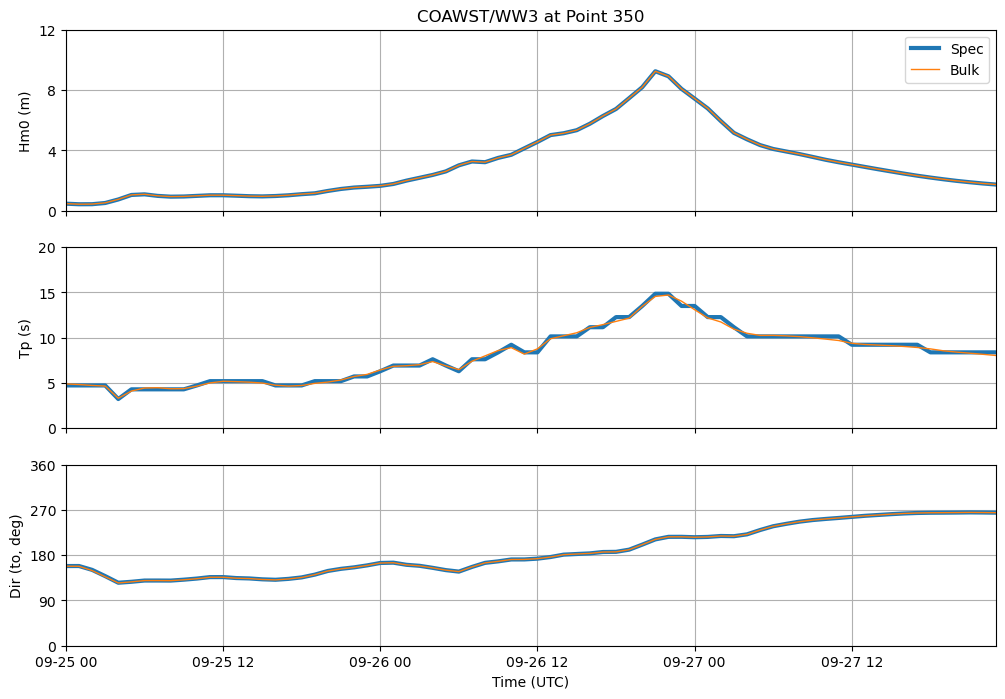

In [25]:
import matplotlib.pyplot as plt
icp = 350
# trim the time
ds_cmp = ds_cmp.sel(time=slice('2024-09-25', '2024-09-27'))
t = ds_cmp['time'].values

fig, ax = plt.subplots( 3, 1, figsize=(12,8), sharex = True )
ax[0].plot( t, ds_cmp['hm0_spec'].values[:,icp],'-', lw=3, label='Spec')
ax[0].plot( t, ds_cmp['hs_bulk'].values[:,icp],'-', lw=1, label='Bulk')
ax[0].set_ylabel('Hm0 (m)')
ax[0].set_yticks( [0, 4., 8,  12])
ax[0].grid(True)
ax[1].plot( t, ds_cmp['tp_spec'].values[:,icp],'-', lw=3, label='Spec')
ax[1].plot( t, ds_cmp['tp_bulk'].values[:,icp],'-', lw=1, label='Bulk')
ax[1].set_ylabel('Tp (s)')
ax[1].set_yticks( [0,5,10,15, 20])
ax[1].grid(True)
ax[2].plot( t, ds_cmp['dir_mean_to_spec'].values[:,icp],'-', lw=3, label='Spec')
ax[2].plot( t, ds_cmp['dir_bulk'].values[:,icp],'-', lw=1, label='Bulk')
ax[2].set_ylabel('Dir (to, deg)')
ax[2].set_xlabel('Time (UTC)')
ax[2].set_yticks( [0.,90.,180., 270., 360])
ax[2].set_ylim( 0, 360 )
ax[2].grid(True)
ax[2].set_xlim( t[0], t[-1] )
ts = f'COAWST/WW3 at Point {icp}'
ax[0].set_title(ts)
ax[0].legend()
plt.savefig( f'comp_coawst_ww3_{icp}.png')